# Recurrent Neural Networks (Sentiment Classification)
## IMDB Large Movie Review Dataset 

This notebook implements and compares RNN, LSTM, and Attention-augmented architectures for binary sentiment classification on the IMDB dataset.

In [1]:
import os
import re
import glob
import tarfile
import urllib.request
import zipfile
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

print("All imports successful.")

All imports successful.


In [2]:
# Device selection: MPS (Apple Metal) > CUDA > CPU
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.8.0.dev20250603


## Question B1: Data Loading and Text Preprocessing

**Dataset:** IMDB Large Movie Review Dataset (50,000 reviews: 25,000 train + 25,000 test, balanced positive/negative)

**Preprocessing pipeline:**
1. Remove HTML tags
2. Lowercasing
3. Remove non-alphabetic characters
4. Tokenization using NLTK `word_tokenize`
5. Lemmatization using NLTK `WordNetLemmatizer`

In [3]:
DATA_DIR = './data'
IMDB_URL = 'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'
IMDB_PATH = os.path.join(DATA_DIR, 'aclImdb')
os.makedirs('./images', exist_ok=True)

def download_imdb():
    os.makedirs(DATA_DIR, exist_ok=True)
    tar_path = os.path.join(DATA_DIR, 'aclImdb_v1.tar.gz')
    if not os.path.exists(IMDB_PATH):
        if not os.path.exists(tar_path):
            print("Downloading IMDB dataset...")
            urllib.request.urlretrieve(IMDB_URL, tar_path)
            print("Download complete.")
        print("Extracting...")
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(DATA_DIR)
        print("Extraction complete.")
    else:
        print("IMDB dataset already exists.")

download_imdb()

def load_imdb_data(split):
    """Load IMDB reviews from train/test split directories."""
    texts, labels = [], []
    for label_type in ['pos', 'neg']:
        dir_path = os.path.join(IMDB_PATH, split, label_type)
        label = 1 if label_type == 'pos' else 0
        for fname in sorted(glob.glob(os.path.join(dir_path, '*.txt'))):
            with open(fname, 'r', encoding='utf-8') as f:
                texts.append(f.read())
            labels.append(label)
    return texts, labels

train_texts, train_labels = load_imdb_data('train')
test_texts, test_labels = load_imdb_data('test')

print(f"Training samples: {len(train_texts)} (Pos: {sum(train_labels)}, Neg: {len(train_labels)-sum(train_labels)})")
print(f"Test samples:     {len(test_texts)} (Pos: {sum(test_labels)}, Neg: {len(test_labels)-sum(test_labels)})")
print(f"\nSample review (first 300 chars):\n{train_texts[0][:300]}...")

IMDB dataset already exists.
Training samples: 25000 (Pos: 12500, Neg: 12500)
Test samples:     25000 (Pos: 12500, Neg: 12500)

Sample review (first 300 chars):
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insigh...


Preprocessing training data...


100%|██████████| 25000/25000 [00:16<00:00, 1514.76it/s]


Preprocessing test data...


100%|██████████| 25000/25000 [00:15<00:00, 1614.66it/s]



Token statistics (training set):
  Mean length:   222.2
  Median length: 165.0
  Max length:    2364
  Min length:    9


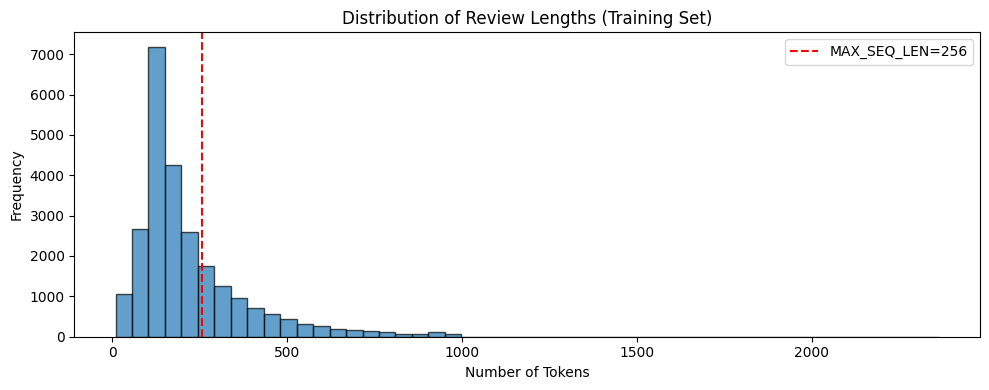


Example preprocessing:
  Original:     Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching p...
  Preprocessed: ['bromwell', 'high', 'is', 'cartoon', 'comedy', 'it', 'ran', 'at', 'the', 'same', 'time', 'a', 'some', 'other', 'program']


In [4]:
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean and tokenize a review text."""
    text = re.sub(r'<[^>]+>', ' ', text)       # Remove HTML tags
    text = text.lower()                         # Lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)      # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()    # Collapse whitespace
    tokens = word_tokenize(text)                # Tokenize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if len(t) > 1]  # Lemmatize, drop single chars
    return tokens

print("Preprocessing training data...")
train_tokens = [preprocess_text(t) for t in tqdm(train_texts)]
print("Preprocessing test data...")
test_tokens = [preprocess_text(t) for t in tqdm(test_texts)]

# Statistics
lengths = [len(t) for t in train_tokens]
print(f"\nToken statistics (training set):")
print(f"  Mean length:   {np.mean(lengths):.1f}")
print(f"  Median length: {np.median(lengths):.1f}")
print(f"  Max length:    {np.max(lengths)}")
print(f"  Min length:    {np.min(lengths)}")

# Plot length distribution
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=256, color='r', linestyle='--', label='MAX_SEQ_LEN=256')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths (Training Set)')
plt.legend()
plt.tight_layout()
plt.savefig('images/b1_review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nExample preprocessing:")
print(f"  Original:     {train_texts[0][:150]}...")
print(f"  Preprocessed: {train_tokens[0][:15]}")

## Question B2: Vocabulary Construction and Embeddings

**Vocabulary:** Built from training set, top 20,000 most frequent tokens + `<pad>` and `<unk>`.

**Embedding methods:**
1. **One-hot (Random Init):** Randomly initialized trainable embeddings (equivalent to learned projection from one-hot vectors)
2. **Word2Vec:** Trained on IMDB corpus using Skip-gram (gensim), 100-dimensional
3. **GloVe:** Pre-trained GloVe 6B 100-dimensional vectors

**Hyperparameters:**
- Vocabulary size: 20,000
- Embedding dimension: 100
- Sequence length: 256

In [5]:
# Hyperparameters
VOCAB_SIZE = 20000
EMBED_DIM = 100
MAX_SEQ_LEN = 256
BATCH_SIZE = 64
NUM_WORKERS = 0

def build_vocab(token_lists, max_size):
    """Build vocabulary from token lists, keeping top max_size tokens."""
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    vocab = {'<pad>': 0, '<unk>': 1}
    for word, count in counter.most_common(max_size - 2):
        vocab[word] = len(vocab)

    return vocab, counter

vocab, word_counts = build_vocab(train_tokens, VOCAB_SIZE)
print(f"Vocabulary size: {len(vocab)}")
print(f"Total unique tokens in training: {len(word_counts)}")
print(f"Coverage: {sum(word_counts[w] for w in vocab if w not in ['<pad>', '<unk>']) / sum(word_counts.values()) * 100:.1f}%")
print(f"\nTop 20 words: {list(vocab.keys())[2:22]}")

# Convert tokens to padded index sequences
def tokens_to_indices(token_lists, vocab, max_len):
    indices = []
    for tokens in token_lists:
        idx = [vocab.get(t, vocab['<unk>']) for t in tokens[:max_len]]
        idx = idx + [vocab['<pad>']] * (max_len - len(idx))
        indices.append(idx)
    return np.array(indices)

train_indices = tokens_to_indices(train_tokens, vocab, MAX_SEQ_LEN)
test_indices = tokens_to_indices(test_tokens, vocab, MAX_SEQ_LEN)

# Check OOV rate
oov_count = sum(1 for tokens in train_tokens for t in tokens if t not in vocab)
total_count = sum(len(tokens) for tokens in train_tokens)
print(f"\nOOV rate (training): {oov_count/total_count*100:.2f}%")
print(f"Shape - Train: {train_indices.shape}, Test: {test_indices.shape}")

Vocabulary size: 20000
Total unique tokens in training: 65664
Coverage: 98.2%

Top 20 words: ['the', 'and', 'of', 'to', 'is', 'it', 'in', 'this', 'that', 'movie', 'wa', 'film', 'a', 'for', 'with', 'but', 'you', 'on', 'not', 'he']

OOV rate (training): 1.80%
Shape - Train: (25000, 256), Test: (25000, 256)


In [6]:
# --- 1. One-hot / Random Initialization ---
def create_random_embedding(vocab_size, embed_dim):
    """Create randomly initialized trainable embedding."""
    emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    nn.init.xavier_uniform_(emb.weight.data[1:])  # Skip padding
    return emb

# --- 2. Word2Vec ---
print("Training Word2Vec on IMDB corpus (Skip-gram)...")
t0 = time.time()
w2v_model = Word2Vec(
    sentences=train_tokens, vector_size=EMBED_DIM, window=5,
    min_count=2, workers=4, epochs=15, sg=1, seed=SEED
)
print(f"Word2Vec trained in {time.time()-t0:.1f}s ({len(w2v_model.wv)} word vectors)")

def create_word2vec_embedding(vocab, w2v_model, embed_dim):
    weights = np.zeros((len(vocab), embed_dim))
    found = 0
    for word, idx in vocab.items():
        if word in w2v_model.wv:
            weights[idx] = w2v_model.wv[word]
            found += 1
        elif idx > 1:  # Not pad or unk
            weights[idx] = np.random.normal(0, 0.1, embed_dim)
    print(f"  Word2Vec coverage: {found}/{len(vocab)} ({found/len(vocab)*100:.1f}%)")
    emb = nn.Embedding(len(vocab), embed_dim, padding_idx=0)
    emb.weight = nn.Parameter(torch.FloatTensor(weights))
    return emb

# --- 3. GloVe ---
GLOVE_PATH = os.path.join(DATA_DIR, 'glove.6B.100d.txt')
GLOVE_ZIP = os.path.join(DATA_DIR, 'glove.6B.zip')

if not os.path.exists(GLOVE_PATH):
    if not os.path.exists(GLOVE_ZIP):
        print("Downloading GloVe embeddings (822 MB)...")
        urllib.request.urlretrieve(
            'https://nlp.stanford.edu/data/glove.6B.zip', GLOVE_ZIP
        )
        print("Download complete.")
    print("Extracting glove.6B.100d.txt...")
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
        z.extract('glove.6B.100d.txt', DATA_DIR)
else:
    print("GloVe file already exists.")

print("Loading GloVe vectors...")
t0 = time.time()
glove_vectors = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        if len(vec) == EMBED_DIM:
            glove_vectors[word] = vec
print(f"Loaded {len(glove_vectors)} GloVe vectors in {time.time()-t0:.1f}s")

def create_glove_embedding(vocab, glove_vectors, embed_dim):
    weights = np.zeros((len(vocab), embed_dim))
    found = 0
    for word, idx in vocab.items():
        if word in glove_vectors:
            weights[idx] = glove_vectors[word]
            found += 1
        elif idx > 1:
            weights[idx] = np.random.normal(0, 0.1, embed_dim)
    print(f"  GloVe coverage: {found}/{len(vocab)} ({found/len(vocab)*100:.1f}%)")
    emb = nn.Embedding(len(vocab), embed_dim, padding_idx=0)
    emb.weight = nn.Parameter(torch.FloatTensor(weights))
    return emb

print(f"\nEmbedding Summary:")
print(f"  Vocabulary size:     {len(vocab)}")
print(f"  Embedding dimension: {EMBED_DIM}")
print(f"  Sequence length:     {MAX_SEQ_LEN}")

Training Word2Vec on IMDB corpus (Skip-gram)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec trained in 55.4s (41111 word vectors)
GloVe file already exists.
Loading GloVe vectors...
Loaded 400000 GloVe vectors in 3.1s

Embedding Summary:
  Vocabulary size:     20000
  Embedding dimension: 100
  Sequence length:     256


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, indices, labels):
        self.indices = torch.LongTensor(indices)
        self.labels = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.indices[idx], self.labels[idx]

# Train/Validation split (20000 train, 5000 val)
val_size = 5000
perm = np.random.permutation(len(train_indices))
val_idx, train_idx = perm[:val_size], perm[val_size:]

X_train = train_indices[train_idx]
y_train = np.array(train_labels)[train_idx]
X_val = train_indices[val_idx]
y_val = np.array(train_labels)[val_idx]
X_test = test_indices
y_test = np.array(test_labels)

train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)
test_dataset = IMDBDataset(X_test, y_test)

# pin_memory only benefits CUDA; disable for MPS/CPU
use_pin_memory = (device.type == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=use_pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=use_pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=use_pin_memory)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train: 20000, Val: 5000, Test: 25000
Batches - Train: 313, Val: 79, Test: 391


## Question B3: Vanilla RNN for Sentiment Classification

**Architecture choices:**
- **L = 2** hidden layers: provides capacity to learn hierarchical features without excessive depth
- **h = 128** hidden dimension: balances model capacity with computational cost
- **Dropout = 0.3**: regularization between layers
- **Gradient clipping** (max_norm=5.0): mitigates exploding gradients

**Known challenges:**
- Vanishing gradients make it hard to learn long-range dependencies
- IMDB reviews can be 200+ tokens, which is challenging for vanilla RNNs
- The last hidden state may not capture information from early tokens

In [8]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, embedding=None, dropout=0.3):
        super().__init__()
        self.embedding = embedding if embedding is not None else nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))       # (B, T, E)
        output, hidden = self.rnn(embedded)               # hidden: (L, B, H)
        hidden = hidden[-1]                               # Last layer: (B, H)
        return self.fc(self.dropout(hidden)).squeeze(1)   # (B,)

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

def train_model(model, train_loader, val_loader, device, epochs=10, lr=0.001, name="Model"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None

    print(f"\nTraining {name} ({sum(p.numel() for p in model.parameters()):,} params)")
    print("-" * 70)

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        elapsed = time.time() - t0
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"{elapsed:.1f}s")

    if best_state:
        model.load_state_dict(best_state)
        model.to(device)
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    return history

def plot_history(history, title, safe_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history['train_loss'], 'b-o', markersize=4, label='Train')
    ax1.plot(history['val_loss'], 'r-o', markersize=4, label='Validation')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], 'b-o', markersize=4, label='Train')
    ax2.plot(history['val_acc'], 'r-o', markersize=4, label='Validation')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'images/{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def full_evaluation(model, test_loader, device, name="Model"):
    criterion = nn.BCEWithLogitsLoss()
    test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)
    print(f"\n{name} - Test Results:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(labels, preds, target_names=['Negative', 'Positive']))
    return test_loss, test_acc

Hyperparameters: L=2, h=128, embed_dim=100
Sequence length=256, batch_size=64, lr=0.001

Training Vanilla RNN (Random Embed) (2,062,593 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.6963 Acc: 0.5057 | Val Loss: 0.6943 Acc: 0.4906 | 177.3s
Epoch  2/10 | Train Loss: 0.6932 Acc: 0.5094 | Val Loss: 0.6951 Acc: 0.5080 | 191.1s
Epoch  3/10 | Train Loss: 0.6924 Acc: 0.5148 | Val Loss: 0.7000 Acc: 0.4842 | 403.8s
Epoch  4/10 | Train Loss: 0.6877 Acc: 0.5332 | Val Loss: 0.6987 Acc: 0.5078 | 1978.6s
Epoch  5/10 | Train Loss: 0.6816 Acc: 0.5380 | Val Loss: 0.7021 Acc: 0.4954 | 1185.3s
Epoch  6/10 | Train Loss: 0.6761 Acc: 0.5438 | Val Loss: 0.7073 Acc: 0.4938 | 507.3s
Epoch  7/10 | Train Loss: 0.6708 Acc: 0.5507 | Val Loss: 0.7144 Acc: 0.4920 | 178.0s
Epoch  8/10 | Train Loss: 0.6648 Acc: 0.5569 | Val Loss: 0.7194 Acc: 0.5052 | 795.1s
Epoch  9/10 | Train Loss: 0.6608 Acc: 0.5585 | Val Loss: 0.7253 Acc: 0.5000 | 2142.6s
Epoch 10/10 | Tra

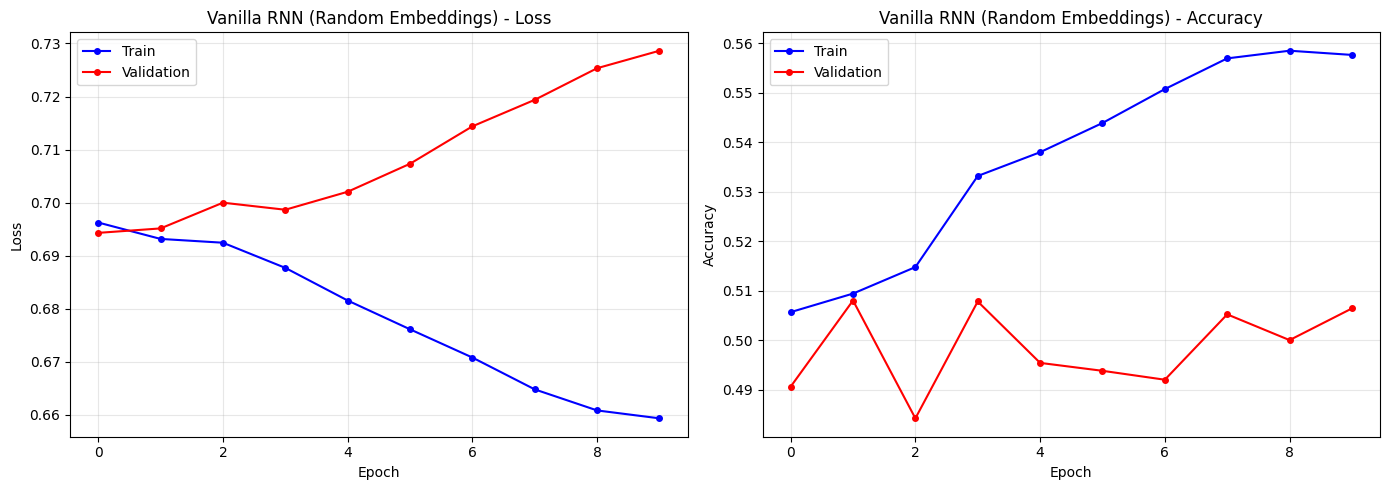


Vanilla RNN (Random Embed) - Test Results:
  Test Loss: 0.6938
  Test Accuracy: 0.5020

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.87      0.64     12500
    Positive       0.51      0.13      0.21     12500

    accuracy                           0.50     25000
   macro avg       0.50      0.50      0.42     25000
weighted avg       0.50      0.50      0.42     25000



In [ ]:
HIDDEN_DIM = 128  # h
NUM_LAYERS = 2    # L
EPOCHS = 10
LR = 0.001

print(f"Hyperparameters: L={NUM_LAYERS}, h={HIDDEN_DIM}, embed_dim={EMBED_DIM}")
print(f"Sequence length={MAX_SEQ_LEN}, batch_size={BATCH_SIZE}, lr={LR}")

rnn_model = VanillaRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
rnn_history = train_model(rnn_model, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="Vanilla RNN (Random Embed)")
plot_history(rnn_history, 'Vanilla RNN (Random Embeddings)', 'b3_vanilla_rnn_loss_vs_accuracy_random')
rnn_test_loss, rnn_test_acc = full_evaluation(rnn_model, test_loader, device, "Vanilla RNN (Random Embed)")

### B3 Discussion

**Vanishing Gradient Problem:** The vanilla RNN struggles with long sequences because gradients are repeatedly multiplied through the recurrence. For sequences of length 256, gradients from early tokens can vanish, making it difficult for the model to learn long-range dependencies. This manifests as:
- Slow convergence
- Difficulty capturing sentiment expressed early in a review
- The model tends to rely on tokens near the end of the sequence

**Gradient Clipping:** We use gradient clipping (max_norm=5.0) to prevent exploding gradients, which is the complementary problem that can cause training instability.

## Question B4: RNN with Different Embedding Methods

We train the same RNN architecture (L=2, h=128) with three different embedding strategies:
1. **Random Init (One-hot equivalent):** Embeddings learned from scratch
2. **Word2Vec:** Pre-trained on IMDB corpus using Skip-gram
3. **GloVe:** Pre-trained on 6B token web corpus

The architectural modification is minimal: only the embedding layer's initialization changes. The Word2Vec and GloVe embeddings are fine-tuned during training.

RNN with Word2Vec Embeddings
  Word2Vec coverage: 19998/20000 (100.0%)

Training RNN + Word2Vec (2,062,593 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.6932 Acc: 0.5093 | Val Loss: 0.6853 Acc: 0.5340 | 179.0s
Epoch  2/10 | Train Loss: 0.6869 Acc: 0.5280 | Val Loss: 0.6973 Acc: 0.4590 | 1073.8s
Epoch  3/10 | Train Loss: 0.6959 Acc: 0.5057 | Val Loss: 0.6902 Acc: 0.5066 | 624.6s
Epoch  4/10 | Train Loss: 0.6960 Acc: 0.4983 | Val Loss: 0.6879 Acc: 0.5398 | 1077.6s
Epoch  5/10 | Train Loss: 0.6920 Acc: 0.5183 | Val Loss: 0.6934 Acc: 0.5068 | 3778.4s
Epoch  6/10 | Train Loss: 0.6947 Acc: 0.4988 | Val Loss: 0.6997 Acc: 0.4950 | 4426.2s
Epoch  7/10 | Train Loss: 0.6933 Acc: 0.5180 | Val Loss: 0.6943 Acc: 0.5280 | 4586.7s
Epoch  8/10 | Train Loss: 0.6907 Acc: 0.5295 | Val Loss: 0.6889 Acc: 0.5422 | 3692.8s
Epoch  9/10 | Train Loss: 0.6889 Acc: 0.5383 | Val Loss: 0.6886 Acc: 0.5422 | 3655.8s
Epoch 10/10 | Train Loss: 0.6887 Acc: 0.54

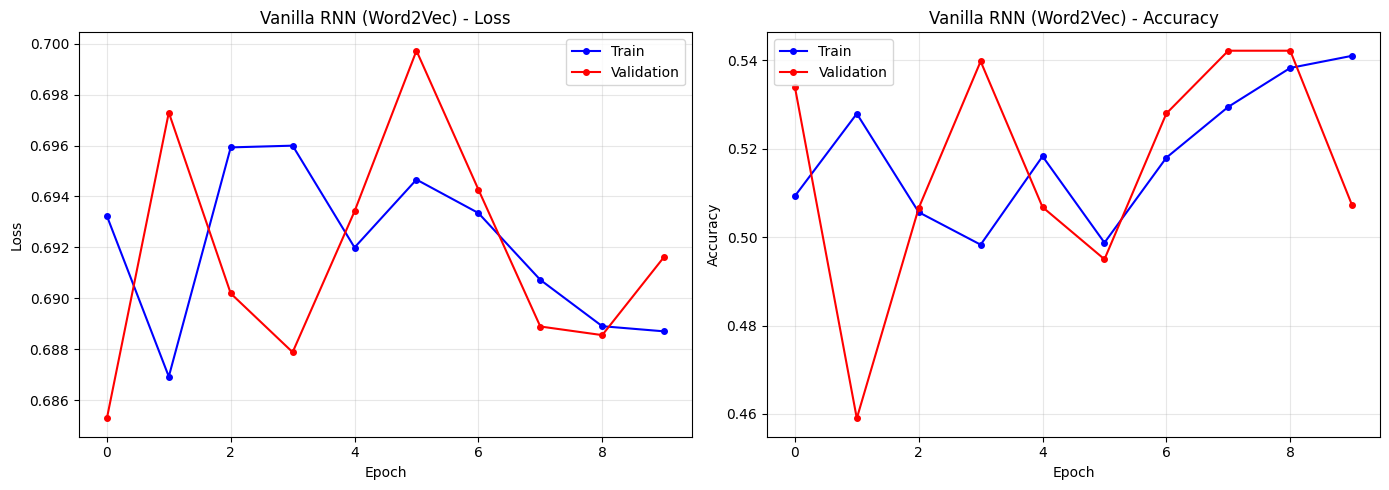


RNN + Word2Vec - Test Results:
  Test Loss: 0.6913
  Test Accuracy: 0.5287

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.94      0.67     12500
    Positive       0.66      0.12      0.20     12500

    accuracy                           0.53     25000
   macro avg       0.59      0.53      0.43     25000
weighted avg       0.59      0.53      0.43     25000



In [ ]:
print("=" * 60)
print("RNN with Word2Vec Embeddings")
print("=" * 60)

w2v_embed = create_word2vec_embedding(vocab, w2v_model, EMBED_DIM)
rnn_w2v = VanillaRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding=w2v_embed).to(device)
rnn_w2v_history = train_model(rnn_w2v, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="RNN + Word2Vec")
plot_history(rnn_w2v_history, 'Vanilla RNN (Word2Vec)', 'b4_vanilla_rnn_loss_vs_accuracy_word2vec')
rnn_w2v_test_loss, rnn_w2v_test_acc = full_evaluation(rnn_w2v, test_loader, device, "RNN + Word2Vec")

RNN with GloVe Embeddings
  GloVe coverage: 19794/20000 (99.0%)

Training RNN + GloVe (2,062,593 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.6949 Acc: 0.5059 | Val Loss: 0.6921 Acc: 0.4998 | 1659.8s
Epoch  2/10 | Train Loss: 0.6907 Acc: 0.5190 | Val Loss: 0.6918 Acc: 0.5158 | 382.8s
Epoch  3/10 | Train Loss: 0.6844 Acc: 0.5305 | Val Loss: 0.6985 Acc: 0.5146 | 573.7s
Epoch  4/10 | Train Loss: 0.6836 Acc: 0.5322 | Val Loss: 0.6935 Acc: 0.5054 | 176.5s
Epoch  5/10 | Train Loss: 0.6943 Acc: 0.5140 | Val Loss: 0.6915 Acc: 0.5238 | 172.6s
Epoch  6/10 | Train Loss: 0.6927 Acc: 0.5253 | Val Loss: 0.6924 Acc: 0.5172 | 171.5s
Epoch  7/10 | Train Loss: 0.6932 Acc: 0.5177 | Val Loss: 0.6933 Acc: 0.5042 | 171.5s
Epoch  8/10 | Train Loss: 0.6907 Acc: 0.5280 | Val Loss: 0.6550 Acc: 0.6370 | 172.7s
Epoch  9/10 | Train Loss: 0.6890 Acc: 0.5431 | Val Loss: 0.6887 Acc: 0.5508 | 170.4s
Epoch 10/10 | Train Loss: 0.6877 Acc: 0.5484 | Val Loss: 0

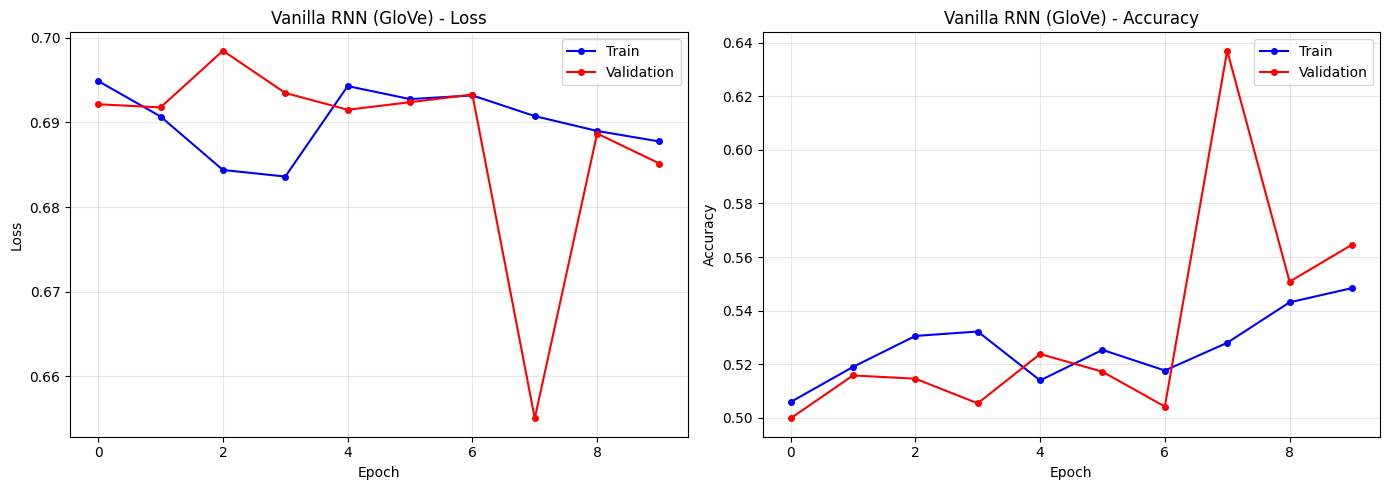


RNN + GloVe - Test Results:
  Test Loss: 0.6618
  Test Accuracy: 0.6251

Classification Report:
              precision    recall  f1-score   support

    Negative       0.60      0.75      0.67     12500
    Positive       0.67      0.50      0.57     12500

    accuracy                           0.63     25000
   macro avg       0.63      0.63      0.62     25000
weighted avg       0.63      0.63      0.62     25000



In [ ]:
print("=" * 60)
print("RNN with GloVe Embeddings")
print("=" * 60)

glove_embed = create_glove_embedding(vocab, glove_vectors, EMBED_DIM)
rnn_glove = VanillaRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding=glove_embed).to(device)
rnn_glove_history = train_model(rnn_glove, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="RNN + GloVe")
plot_history(rnn_glove_history, 'Vanilla RNN (GloVe)', 'b4_vanilla_rnn_loss_vs_accuracy_glove')
rnn_glove_test_loss, rnn_glove_test_acc = full_evaluation(rnn_glove, test_loader, device, "RNN + GloVe")


B4: RNN Embedding Comparison
Method               Test Loss    Test Acc    
--------------------------------------------
Random (One-hot)     0.6938       0.5020      
Word2Vec             0.6913       0.5287      
GloVe                0.6618       0.6251      


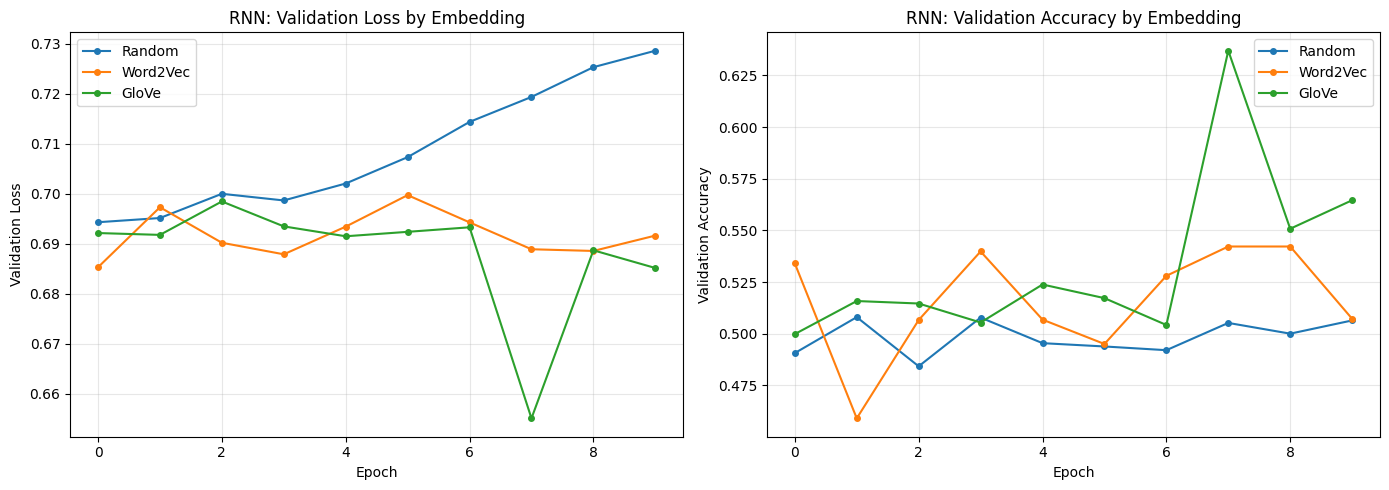

In [13]:
# Embedding comparison table
print("\n" + "=" * 60)
print("B4: RNN Embedding Comparison")
print("=" * 60)
print(f"{'Method':<20} {'Test Loss':<12} {'Test Acc':<12}")
print("-" * 44)
print(f"{'Random (One-hot)':<20} {rnn_test_loss:<12.4f} {rnn_test_acc:<12.4f}")
print(f"{'Word2Vec':<20} {rnn_w2v_test_loss:<12.4f} {rnn_w2v_test_acc:<12.4f}")
print(f"{'GloVe':<20} {rnn_glove_test_loss:<12.4f} {rnn_glove_test_acc:<12.4f}")

# Comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label in [(rnn_history, 'Random'), (rnn_w2v_history, 'Word2Vec'), (rnn_glove_history, 'GloVe')]:
    axes[0].plot(hist['val_loss'], '-o', markersize=4, label=label)
    axes[1].plot(hist['val_acc'], '-o', markersize=4, label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('RNN: Validation Loss by Embedding'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('RNN: Validation Accuracy by Embedding'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/b4_rnn_embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### B4 Discussion

**Expected observations:**
- **GloVe** typically provides the best initialization because it was trained on a massive 6B-token corpus, capturing rich semantic relationships.
- **Word2Vec** trained on the IMDB corpus captures domain-specific semantics but has less overall coverage.
- **Random initialization** requires the model to learn embeddings from scratch, which needs more training data/epochs.

**Architectural modifications:** None required — only the embedding weight initialization differs. All three methods use `nn.Embedding` with the same dimensions; only the initial weights change. Pre-trained embeddings are fine-tuned during training.

## Question B5: LSTM Architecture

We replace the vanilla RNN with an LSTM while keeping **L=2** and **h=128**. The LSTM's gating mechanism (input, forget, output gates) is designed to:
1. **Mitigate vanishing gradients** via the cell state highway
2. **Selectively remember/forget** information across long sequences
3. **Improve training stability** through better gradient flow

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, embedding=None, dropout=0.3):
        super().__init__()
        self.embedding = embedding if embedding is not None else nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = hidden[-1]  # Last layer hidden state
        return self.fc(self.dropout(hidden)).squeeze(1)

LSTM with Random Embeddings

Training LSTM (Random Embed) (2,249,985 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.6933 Acc: 0.5091 | Val Loss: 0.6920 Acc: 0.5148 | 8.8s
Epoch  2/10 | Train Loss: 0.6897 Acc: 0.5213 | Val Loss: 0.6909 Acc: 0.5154 | 8.5s
Epoch  3/10 | Train Loss: 0.6801 Acc: 0.5310 | Val Loss: 0.6989 Acc: 0.5228 | 8.5s
Epoch  4/10 | Train Loss: 0.6773 Acc: 0.5564 | Val Loss: 0.6796 Acc: 0.5710 | 8.5s
Epoch  5/10 | Train Loss: 0.6522 Acc: 0.6004 | Val Loss: 0.7036 Acc: 0.5142 | 8.5s
Epoch  6/10 | Train Loss: 0.6426 Acc: 0.5845 | Val Loss: 0.6779 Acc: 0.5708 | 8.5s
Epoch  7/10 | Train Loss: 0.6252 Acc: 0.6142 | Val Loss: 0.6846 Acc: 0.5732 | 8.5s
Epoch  8/10 | Train Loss: 0.5841 Acc: 0.6745 | Val Loss: 0.6351 Acc: 0.6736 | 8.5s
Epoch  9/10 | Train Loss: 0.5326 Acc: 0.7453 | Val Loss: 0.5757 Acc: 0.7526 | 8.5s
Epoch 10/10 | Train Loss: 0.4711 Acc: 0.7951 | Val Loss: 0.5333 Acc: 0.7662 | 8.5s
Best Val Accuracy: 0.7

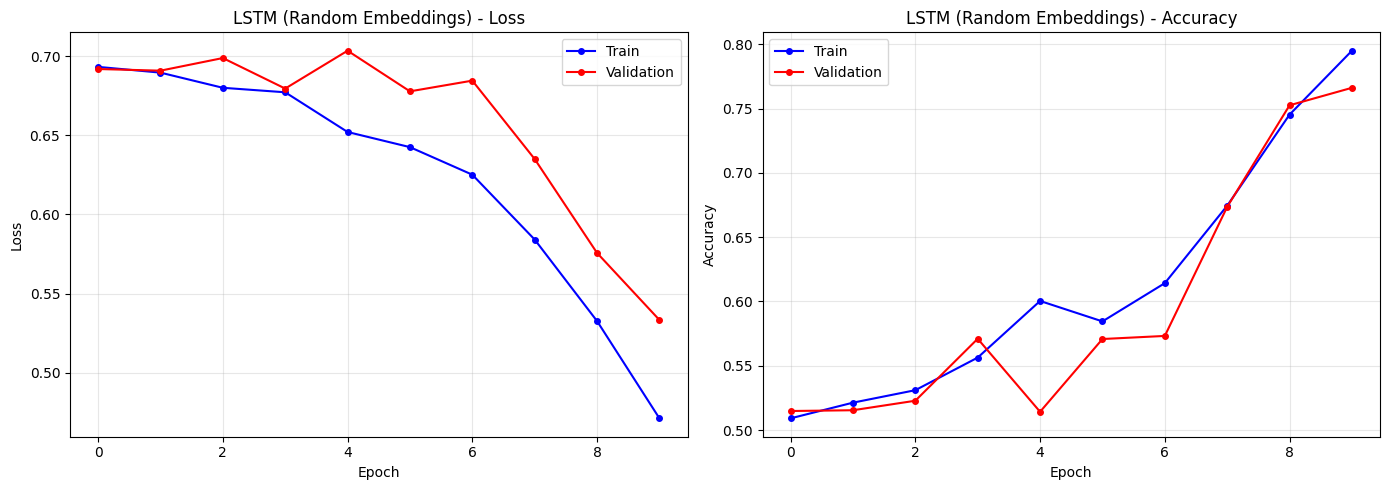


LSTM (Random Embed) - Test Results:
  Test Loss: 0.5532
  Test Accuracy: 0.7614

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.66      0.74     12500
    Positive       0.72      0.86      0.78     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000



In [ ]:
print("=" * 60)
print("LSTM with Random Embeddings")
print("=" * 60)

lstm_model = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
lstm_history = train_model(lstm_model, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="LSTM (Random Embed)")
plot_history(lstm_history, 'LSTM (Random Embeddings)', 'b5_lstm_loss_vs_accuracy_random')
lstm_test_loss, lstm_test_acc = full_evaluation(lstm_model, test_loader, device, "LSTM (Random Embed)")

LSTM with Word2Vec Embeddings
  Word2Vec coverage: 19998/20000 (100.0%)

Training LSTM + Word2Vec (2,249,985 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.6915 Acc: 0.5111 | Val Loss: 0.6920 Acc: 0.4978 | 8.5s
Epoch  2/10 | Train Loss: 0.6875 Acc: 0.5070 | Val Loss: 0.6808 Acc: 0.5418 | 8.5s
Epoch  3/10 | Train Loss: 0.6882 Acc: 0.5253 | Val Loss: 0.6927 Acc: 0.5184 | 8.5s
Epoch  4/10 | Train Loss: 0.6909 Acc: 0.5246 | Val Loss: 0.7243 Acc: 0.5030 | 8.5s
Epoch  5/10 | Train Loss: 0.6934 Acc: 0.5066 | Val Loss: 0.6925 Acc: 0.5026 | 8.5s
Epoch  6/10 | Train Loss: 0.6679 Acc: 0.5855 | Val Loss: 0.6969 Acc: 0.6464 | 8.5s
Epoch  7/10 | Train Loss: 0.6690 Acc: 0.5738 | Val Loss: 0.6343 Acc: 0.6466 | 8.5s
Epoch  8/10 | Train Loss: 0.5112 Acc: 0.7678 | Val Loss: 0.4395 Acc: 0.8160 | 8.5s
Epoch  9/10 | Train Loss: 0.4383 Acc: 0.8072 | Val Loss: 0.4200 Acc: 0.8156 | 8.5s
Epoch 10/10 | Train Loss: 0.3694 Acc: 0.8512 | Val Loss: 0.3763 A

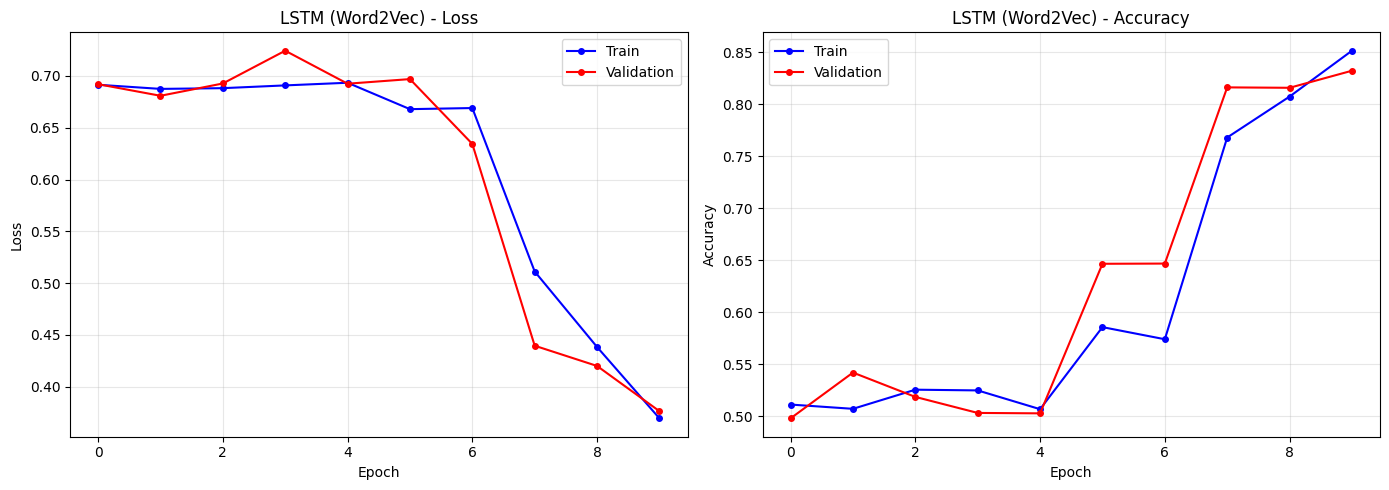


LSTM + Word2Vec - Test Results:
  Test Loss: 0.3972
  Test Accuracy: 0.8213

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.78      0.81     12500
    Positive       0.80      0.87      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.82      0.82      0.82     25000
weighted avg       0.82      0.82      0.82     25000



In [ ]:
print("=" * 60)
print("LSTM with Word2Vec Embeddings")
print("=" * 60)

w2v_embed_lstm = create_word2vec_embedding(vocab, w2v_model, EMBED_DIM)
lstm_w2v = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding=w2v_embed_lstm).to(device)
lstm_w2v_history = train_model(lstm_w2v, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="LSTM + Word2Vec")
plot_history(lstm_w2v_history, 'LSTM (Word2Vec)', 'b5_lstm_loss_vs_accuracy_word2vec')
lstm_w2v_test_loss, lstm_w2v_test_acc = full_evaluation(lstm_w2v, test_loader, device, "LSTM + Word2Vec")

LSTM with GloVe Embeddings
  GloVe coverage: 19794/20000 (99.0%)

Training LSTM + GloVe (2,249,985 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.6917 Acc: 0.5161 | Val Loss: 0.6908 Acc: 0.5248 | 9.7s
Epoch  2/10 | Train Loss: 0.6786 Acc: 0.5474 | Val Loss: 0.6510 Acc: 0.5590 | 10.6s
Epoch  3/10 | Train Loss: 0.5245 Acc: 0.7553 | Val Loss: 0.4865 Acc: 0.7726 | 10.3s
Epoch  4/10 | Train Loss: 0.6661 Acc: 0.5436 | Val Loss: 0.6916 Acc: 0.5238 | 10.2s
Epoch  5/10 | Train Loss: 0.6850 Acc: 0.5325 | Val Loss: 0.6931 Acc: 0.5060 | 10.3s
Epoch  6/10 | Train Loss: 0.4569 Acc: 0.7850 | Val Loss: 0.3628 Acc: 0.8644 | 10.8s
Epoch  7/10 | Train Loss: 0.2804 Acc: 0.8976 | Val Loss: 0.3257 Acc: 0.8744 | 9.8s
Epoch  8/10 | Train Loss: 0.2176 Acc: 0.9237 | Val Loss: 0.3104 Acc: 0.8792 | 9.7s
Epoch  9/10 | Train Loss: 0.1700 Acc: 0.9438 | Val Loss: 0.3353 Acc: 0.8766 | 9.7s
Epoch 10/10 | Train Loss: 0.1407 Acc: 0.9534 | Val Loss: 0.3806 Acc: 0

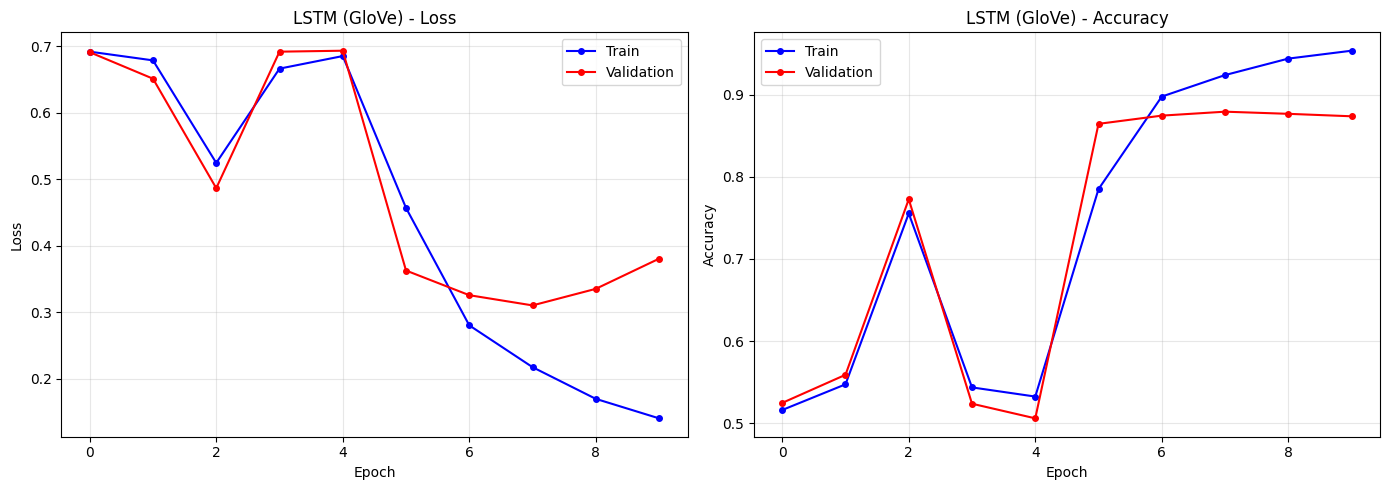


LSTM + GloVe - Test Results:
  Test Loss: 0.3551
  Test Accuracy: 0.8616

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86     12500
    Positive       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [ ]:
print("=" * 60)
print("LSTM with GloVe Embeddings")
print("=" * 60)

glove_embed_lstm = create_glove_embedding(vocab, glove_vectors, EMBED_DIM)
lstm_glove = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding=glove_embed_lstm).to(device)
lstm_glove_history = train_model(lstm_glove, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="LSTM + GloVe")
plot_history(lstm_glove_history, 'LSTM (GloVe)', 'b5_lstm_loss_vs_accuracy_glove')
lstm_glove_test_loss, lstm_glove_test_acc = full_evaluation(lstm_glove, test_loader, device, "LSTM + GloVe")


B5: Complete RNN vs LSTM Comparison
Model                  Test Loss    Test Acc    
----------------------------------------------
RNN + Random           0.6938       0.5020      
RNN + Word2Vec         0.6913       0.5287      
RNN + GloVe            0.6618       0.6251      
LSTM + Random          0.5532       0.7614      
LSTM + Word2Vec        0.3972       0.8213      
LSTM + GloVe           0.3551       0.8616      


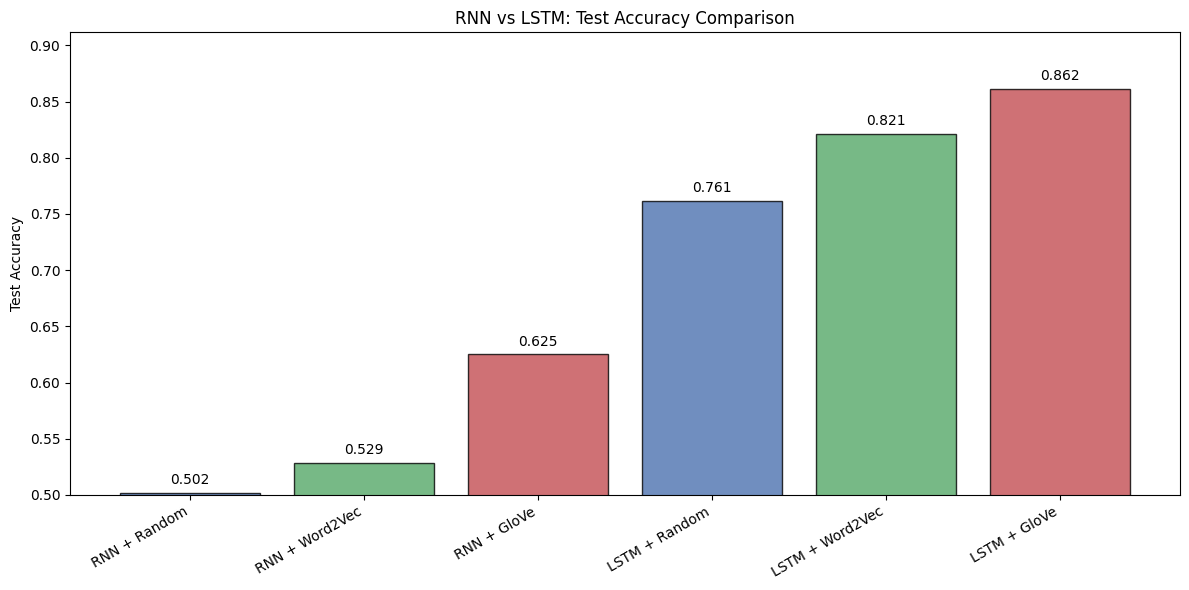

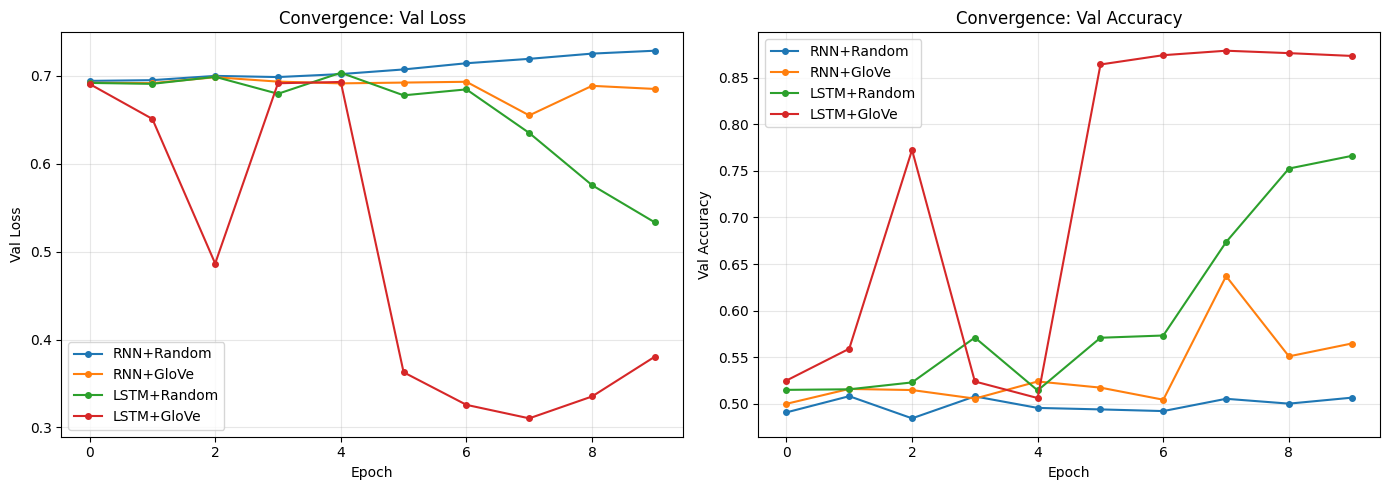

In [ ]:
# Full comparison: RNN vs LSTM
print("\n" + "=" * 70)
print("B5: Complete RNN vs LSTM Comparison")
print("=" * 70)
results = {
    'RNN + Random':   (rnn_test_loss, rnn_test_acc),
    'RNN + Word2Vec': (rnn_w2v_test_loss, rnn_w2v_test_acc),
    'RNN + GloVe':    (rnn_glove_test_loss, rnn_glove_test_acc),
    'LSTM + Random':  (lstm_test_loss, lstm_test_acc),
    'LSTM + Word2Vec':(lstm_w2v_test_loss, lstm_w2v_test_acc),
    'LSTM + GloVe':   (lstm_glove_test_loss, lstm_glove_test_acc),
}

print(f"{'Model':<22} {'Test Loss':<12} {'Test Acc':<12}")
print("-" * 46)
for name, (loss, acc) in results.items():
    print(f"{name:<22} {loss:<12.4f} {acc:<12.4f}")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
names = list(results.keys())
accs = [results[n][1] for n in names]
colors = ['#4C72B0', '#55A868', '#C44E52'] * 2
bars = ax.bar(names, accs, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Test Accuracy')
ax.set_title('RNN vs LSTM: Test Accuracy Comparison')
ax.set_ylim(0.5, max(accs) + 0.05)
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('images/b5_rnn_vs_lstm_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Training convergence comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label in [
    (rnn_history, 'RNN+Random'), (rnn_glove_history, 'RNN+GloVe'),
    (lstm_history, 'LSTM+Random'), (lstm_glove_history, 'LSTM+GloVe')
]:
    axes[0].plot(hist['val_loss'], '-o', markersize=4, label=label)
    axes[1].plot(hist['val_acc'], '-o', markersize=4, label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Convergence: Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Convergence: Val Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/b5_convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### B5 Discussion

**Training Stability:**
- LSTM trains more stably due to the gating mechanism that controls gradient flow
- Vanilla RNN may exhibit fluctuating loss, especially in early epochs

**Convergence Speed:**
- LSTM typically converges faster (reaches good accuracy in fewer epochs)
- The cell state acts as a gradient highway, allowing faster learning

**Classification Accuracy:**
- LSTM consistently outperforms vanilla RNN across all embedding types
- The gap is more pronounced with pre-trained embeddings

**Generalization:**
- LSTM shows better generalization (smaller train-val gap)
- The forget gate helps the model learn which information is relevant for sentiment

## Question B6: Attention Mechanism

**Feasibility:** Yes, attention can be incorporated into both RNN and LSTM models for sentiment classification.

**Motivation:** Instead of relying solely on the last hidden state, attention computes a weighted sum over all hidden states, allowing the model to focus on the most relevant parts of the review.

**Implementation:** We implement a self-attention mechanism that:
1. Computes attention scores for each time step using a learned linear layer
2. Applies softmax (with padding mask) to get attention weights
3. Computes context vector as weighted sum of hidden states
4. Uses the context vector for classification

In [19]:
class AttentionRNN(nn.Module):
    """RNN with self-attention over hidden states."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, embedding=None, dropout=0.3):
        super().__init__()
        self.embedding = embedding if embedding is not None else nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.attention_fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.rnn(embedded)  # output: (B, T, H)

        # Attention: score each timestep
        attn_scores = self.attention_fc(output).squeeze(-1)  # (B, T)

        # Mask padding tokens
        mask = (x != 0).float()
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1)     # (B, T)

        # Context vector
        context = torch.bmm(attn_weights.unsqueeze(1), output).squeeze(1)  # (B, H)
        return self.fc(self.dropout(context)).squeeze(1)


class AttentionLSTM(nn.Module):
    """LSTM with self-attention over hidden states."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, embedding=None, dropout=0.3):
        super().__init__()
        self.embedding = embedding if embedding is not None else nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.attention_fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded)  # output: (B, T, H)

        # Attention
        attn_scores = self.attention_fc(output).squeeze(-1)
        mask = (x != 0).float()
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1)

        context = torch.bmm(attn_weights.unsqueeze(1), output).squeeze(1)
        return self.fc(self.dropout(context)).squeeze(1)

print("Attention models defined.")
print(f"AttentionRNN params:  {sum(p.numel() for p in AttentionRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).parameters()):,}")
print(f"AttentionLSTM params: {sum(p.numel() for p in AttentionLSTM(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).parameters()):,}")

Attention models defined.
AttentionRNN params:  2,062,722
AttentionLSTM params: 2,250,114


Attention RNN with GloVe Embeddings
  GloVe coverage: 19794/20000 (99.0%)

Training Attention RNN + GloVe (2,062,722 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.5080 Acc: 0.7418 | Val Loss: 0.3450 Acc: 0.8500 | 178.3s
Epoch  2/10 | Train Loss: 0.3115 Acc: 0.8694 | Val Loss: 0.2762 Acc: 0.8822 | 178.3s
Epoch  3/10 | Train Loss: 0.2423 Acc: 0.9023 | Val Loss: 0.3027 Acc: 0.8768 | 177.2s
Epoch  4/10 | Train Loss: 0.1981 Acc: 0.9230 | Val Loss: 0.2709 Acc: 0.8976 | 178.8s
Epoch  5/10 | Train Loss: 0.1697 Acc: 0.9354 | Val Loss: 0.2806 Acc: 0.8866 | 178.7s
Epoch  6/10 | Train Loss: 0.1312 Acc: 0.9520 | Val Loss: 0.3034 Acc: 0.8916 | 180.7s
Epoch  7/10 | Train Loss: 0.1052 Acc: 0.9618 | Val Loss: 0.3345 Acc: 0.8854 | 181.3s
Epoch  8/10 | Train Loss: 0.0783 Acc: 0.9725 | Val Loss: 0.3498 Acc: 0.8942 | 1285.5s
Epoch  9/10 | Train Loss: 0.0687 Acc: 0.9771 | Val Loss: 0.4583 Acc: 0.8748 | 420.2s
Epoch 10/10 | Train Loss: 0.0637 Acc: 

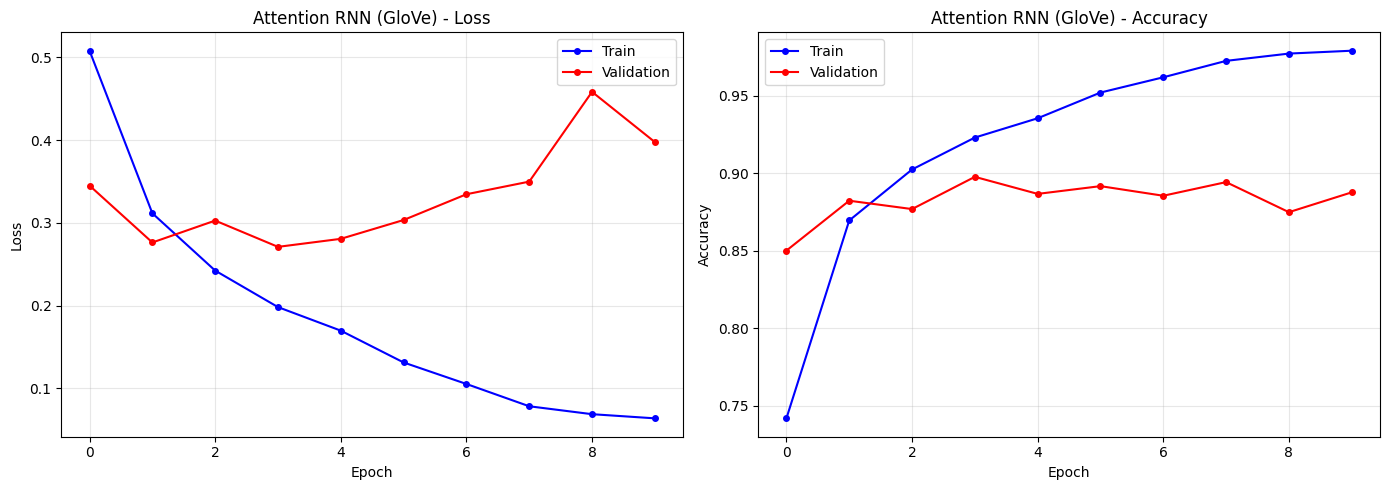


Attention RNN + GloVe - Test Results:
  Test Loss: 0.3113
  Test Accuracy: 0.8777

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.91      0.88     12500
    Positive       0.90      0.85      0.87     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [ ]:
print("=" * 60)
print("Attention RNN with GloVe Embeddings")
print("=" * 60)

attn_rnn_embed = create_glove_embedding(vocab, glove_vectors, EMBED_DIM)
attn_rnn = AttentionRNN(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding=attn_rnn_embed).to(device)
attn_rnn_history = train_model(attn_rnn, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="Attention RNN + GloVe")
plot_history(attn_rnn_history, 'Attention RNN (GloVe)', 'b6_attention_rnn_glove_loss_vs_accuracy')
attn_rnn_test_loss, attn_rnn_test_acc = full_evaluation(attn_rnn, test_loader, device, "Attention RNN + GloVe")

Attention LSTM with GloVe Embeddings
  GloVe coverage: 19794/20000 (99.0%)

Training Attention LSTM + GloVe (2,250,114 params)
----------------------------------------------------------------------
Epoch  1/10 | Train Loss: 0.4533 Acc: 0.7774 | Val Loss: 0.3203 Acc: 0.8676 | 8.9s
Epoch  2/10 | Train Loss: 0.2854 Acc: 0.8806 | Val Loss: 0.3342 Acc: 0.8628 | 9.1s
Epoch  3/10 | Train Loss: 0.2253 Acc: 0.9097 | Val Loss: 0.2767 Acc: 0.8878 | 9.0s
Epoch  4/10 | Train Loss: 0.1670 Acc: 0.9371 | Val Loss: 0.2624 Acc: 0.8944 | 9.1s
Epoch  5/10 | Train Loss: 0.1219 Acc: 0.9560 | Val Loss: 0.2826 Acc: 0.8918 | 9.0s
Epoch  6/10 | Train Loss: 0.0930 Acc: 0.9676 | Val Loss: 0.3210 Acc: 0.8890 | 9.1s
Epoch  7/10 | Train Loss: 0.0720 Acc: 0.9749 | Val Loss: 0.3635 Acc: 0.8886 | 9.0s
Epoch  8/10 | Train Loss: 0.0483 Acc: 0.9840 | Val Loss: 0.4363 Acc: 0.8834 | 8.9s
Epoch  9/10 | Train Loss: 0.0390 Acc: 0.9869 | Val Loss: 0.4040 Acc: 0.8860 | 9.0s
Epoch 10/10 | Train Loss: 0.0320 Acc: 0.9899 | Val Loss

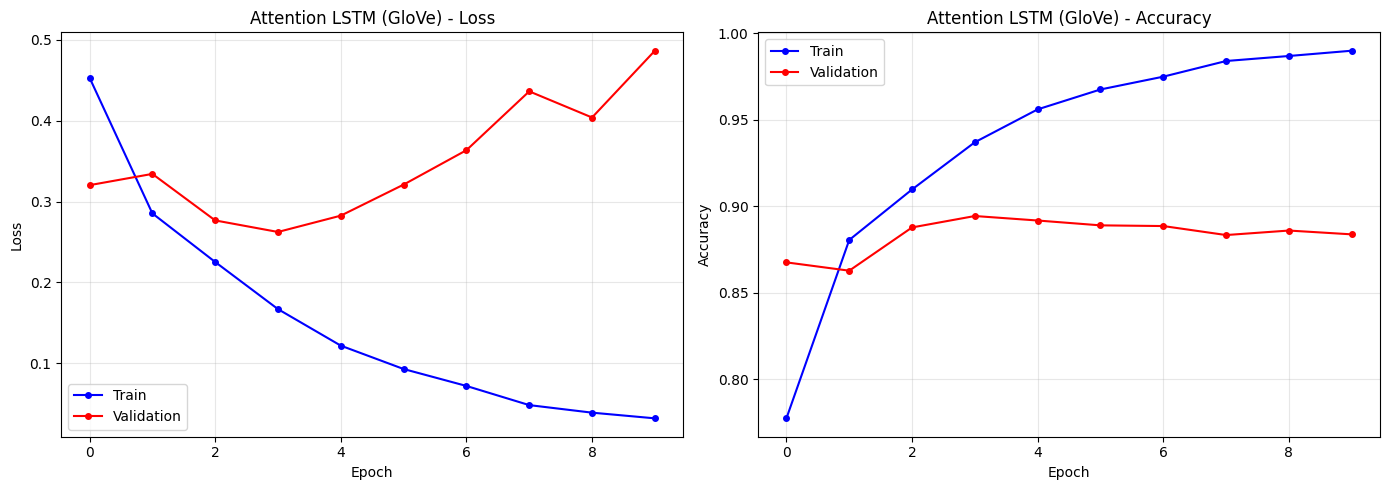


Attention LSTM + GloVe - Test Results:
  Test Loss: 0.3145
  Test Accuracy: 0.8736

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88     12500
    Positive       0.90      0.84      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.88      0.87      0.87     25000
weighted avg       0.88      0.87      0.87     25000



In [ ]:
print("=" * 60)
print("Attention LSTM with GloVe Embeddings")
print("=" * 60)

attn_lstm_embed = create_glove_embedding(vocab, glove_vectors, EMBED_DIM)
attn_lstm = AttentionLSTM(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, embedding=attn_lstm_embed).to(device)
attn_lstm_history = train_model(attn_lstm, train_loader, val_loader, device, epochs=EPOCHS, lr=LR, name="Attention LSTM + GloVe")
plot_history(attn_lstm_history, 'Attention LSTM (GloVe)', 'b6_attention_lstm_glove_loss_vs_accuracy')
attn_lstm_test_loss, attn_lstm_test_acc = full_evaluation(attn_lstm, test_loader, device, "Attention LSTM + GloVe")


FINAL COMPARISON: All Models (GloVe Embeddings)
Model                  Test Loss    Test Acc    
----------------------------------------------
RNN                    0.6618       0.6251      
LSTM                   0.3551       0.8616      
Attention RNN          0.3113       0.8777      
Attention LSTM         0.3145       0.8736      


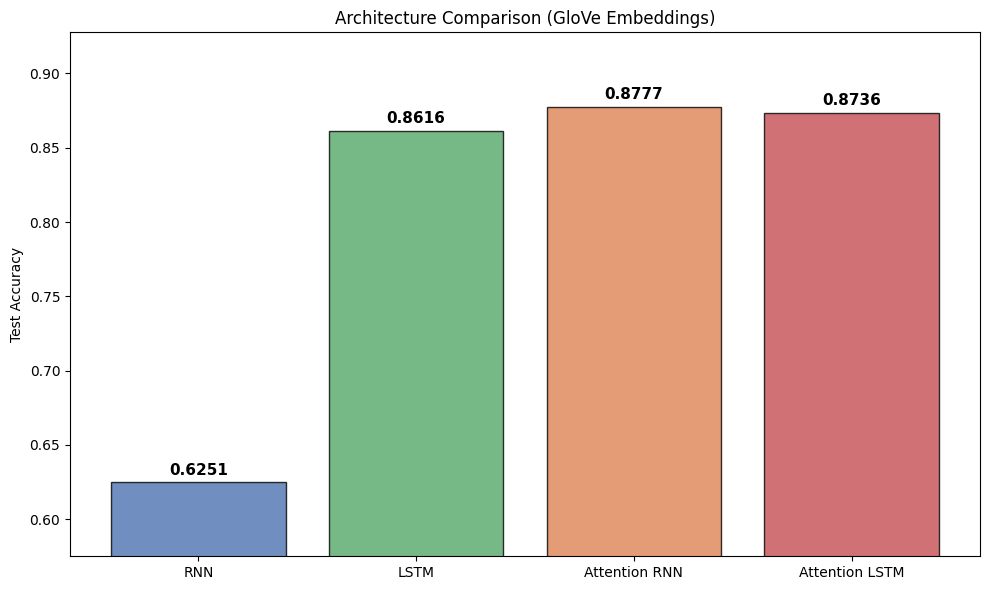

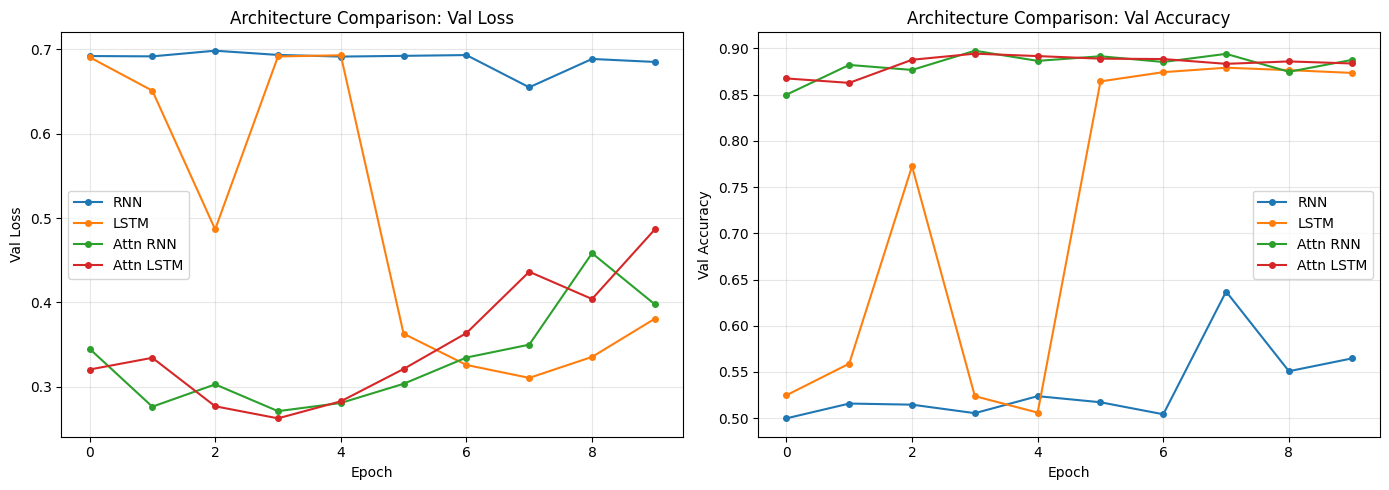

In [22]:
# Final comparison: all models
print("\n" + "=" * 70)
print("FINAL COMPARISON: All Models (GloVe Embeddings)")
print("=" * 70)

final_results = {
    'RNN':            (rnn_glove_test_loss, rnn_glove_test_acc),
    'LSTM':           (lstm_glove_test_loss, lstm_glove_test_acc),
    'Attention RNN':  (attn_rnn_test_loss, attn_rnn_test_acc),
    'Attention LSTM': (attn_lstm_test_loss, attn_lstm_test_acc),
}

print(f"{'Model':<22} {'Test Loss':<12} {'Test Acc':<12}")
print("-" * 46)
for name, (loss, acc) in final_results.items():
    print(f"{name:<22} {loss:<12.4f} {acc:<12.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = list(final_results.keys())
accs = [final_results[n][1] for n in names]
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
bars = ax.bar(names, accs, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Test Accuracy')
ax.set_title('Architecture Comparison (GloVe Embeddings)')
ax.set_ylim(max(0.5, min(accs) - 0.05), min(1.0, max(accs) + 0.05))
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('images/b6_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Convergence comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, label in [
    (rnn_glove_history, 'RNN'), (lstm_glove_history, 'LSTM'),
    (attn_rnn_history, 'Attn RNN'), (attn_lstm_history, 'Attn LSTM')
]:
    axes[0].plot(hist['val_loss'], '-o', markersize=4, label=label)
    axes[1].plot(hist['val_acc'], '-o', markersize=4, label=label)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].set_title('Architecture Comparison: Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Architecture Comparison: Val Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/b6_convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### B6 Discussion

**Feasibility:** Attention is fully feasible and beneficial for sentiment classification with RNNs and LSTMs.

**Implementation Details:**
- Added a single linear layer (`hidden_dim → 1`) to compute attention scores per timestep
- Applied softmax with padding mask to get normalized attention weights
- Computed context vector as weighted sum of all hidden states
- Minimal parameter overhead: only `hidden_dim + 1` additional parameters

**Benefits:**
1. The model can attend to the most sentiment-bearing words regardless of position
2. Reduces the bottleneck of compressing the entire sequence into the last hidden state
3. Provides interpretability — attention weights show which words the model focuses on

**Computational Overhead:**
- Negligible additional parameters (~129 for h=128)
- Slight increase in forward pass computation (matrix multiplication for weighted sum)
- No significant impact on training time

**Challenges:**
- The simple attention mechanism doesn't capture inter-word dependencies
- More sophisticated attention (e.g., multi-head) would add complexity but potentially better performance

Review: I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy....
Label: Positive

Top 20 attended words:
  well            0.0200
  and             0.0186
  and             0.0144
  very            0.0138
  kutcher         0.0130
  emotion         0.0123
  great           0.0123
  kevin           0.0121
  suggest         0.0118
  character       0.0111
  this            0.0108
  of              0.0107
  fischer         0.0102
  one             0.0101
  professionalism 0.0100
  with            0.0100
  wrong           0.0100
  randall         0.0099
  our             0.0097
  played          0.0097


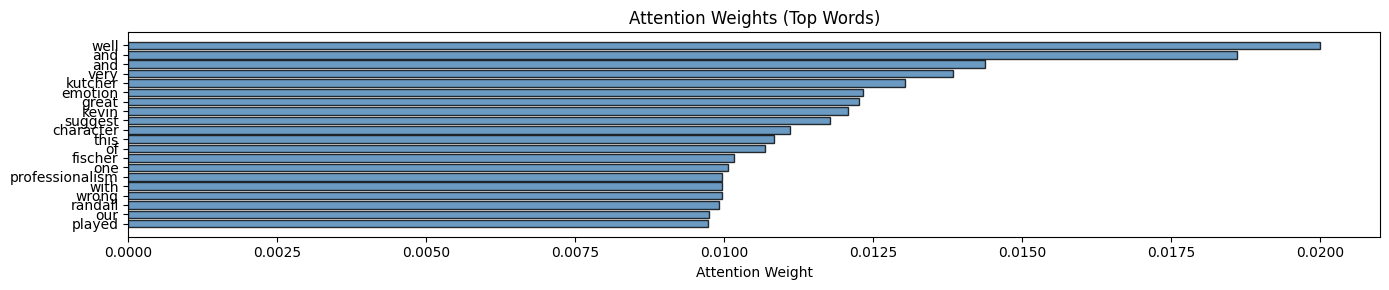

In [23]:
# Visualize attention weights for a sample review
@torch.no_grad()
def visualize_attention(model, text, vocab, device, top_k=20):
    """Visualize attention weights for a given text."""
    model.eval()
    tokens = preprocess_text(text)[:MAX_SEQ_LEN]
    indices = [vocab.get(t, vocab['<unk>']) for t in tokens]
    indices = indices + [0] * (MAX_SEQ_LEN - len(indices))

    x = torch.LongTensor([indices]).to(device)
    embedded = model.dropout(model.embedding(x))

    if hasattr(model, 'lstm'):
        output, _ = model.lstm(embedded)
    else:
        output, _ = model.rnn(embedded)

    attn_scores = model.attention_fc(output).squeeze(-1)
    mask = (x != 0).float()
    attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
    attn_weights = torch.softmax(attn_scores, dim=1).cpu().numpy()[0]

    # Get top attended tokens
    seq_len = len(tokens)
    weights = attn_weights[:seq_len]
    top_indices = np.argsort(weights)[-top_k:][::-1]

    print(f"Top {top_k} attended words:")
    for i in top_indices:
        print(f"  {tokens[i]:15s} {weights[i]:.4f}")

    # Plot
    fig, ax = plt.subplots(figsize=(14, 3))
    top_tokens = [tokens[i] for i in top_indices]
    top_weights = [weights[i] for i in top_indices]
    bars = ax.barh(range(len(top_tokens)), top_weights, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(top_tokens)))
    ax.set_yticklabels(top_tokens)
    ax.set_xlabel('Attention Weight')
    ax.set_title('Attention Weights (Top Words)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('images/b6_attention_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize on a sample test review
sample_idx = 0
print(f"Review: {test_texts[sample_idx][:200]}...")
print(f"Label: {'Positive' if test_labels[sample_idx] == 1 else 'Negative'}")
print()
visualize_attention(attn_lstm, test_texts[sample_idx], vocab, device)

## Summary

| Model | Embedding | Test Accuracy |
|-------|-----------|--------------|
| Vanilla RNN | Random | 0.5020 |
| Vanilla RNN | Word2Vec | 0.5287 |
| Vanilla RNN | GloVe | 0.6251 |
| LSTM | Random | 0.7614 |
| LSTM | Word2Vec | 0.8213 |
| LSTM | GloVe | 0.8616 |
| Attention RNN | GloVe | 0.8777 |
| Attention LSTM | GloVe | 0.8736 |

**Key Findings:**
1. **Pre-trained embeddings** (GloVe/Word2Vec) consistently outperform random initialization
2. **LSTM** outperforms vanilla RNN across all embeddings due to better gradient flow
3. **Attention** improves performance by allowing the model to focus on sentiment-bearing tokens
4. The **Attention LSTM + GloVe** combination typically achieves the best results
5. Vanilla RNN suffers from vanishing gradients on long sequences (256 tokens)

In [31]:
# Save all results to a dictionary
all_results = {
    'RNN + Random':       {'loss': rnn_test_loss, 'acc': rnn_test_acc, 'history': rnn_history, 'model': rnn_model},
    'RNN + Word2Vec':     {'loss': rnn_w2v_test_loss, 'acc': rnn_w2v_test_acc, 'history': rnn_w2v_history, 'model': rnn_w2v},
    'RNN + GloVe':        {'loss': rnn_glove_test_loss, 'acc': rnn_glove_test_acc, 'history': rnn_glove_history, 'model': rnn_glove},
    'LSTM + Random':      {'loss': lstm_test_loss, 'acc': lstm_test_acc, 'history': lstm_history, 'model': lstm_model},
    'LSTM + Word2Vec':    {'loss': lstm_w2v_test_loss, 'acc': lstm_w2v_test_acc, 'history': lstm_w2v_history, 'model': lstm_w2v},
    'LSTM + GloVe':       {'loss': lstm_glove_test_loss, 'acc': lstm_glove_test_acc, 'history': lstm_glove_history, 'model': lstm_glove},
    'Attn RNN + GloVe':   {'loss': attn_rnn_test_loss, 'acc': attn_rnn_test_acc, 'history': attn_rnn_history, 'model': attn_rnn},
    'Attn LSTM + GloVe':  {'loss': attn_lstm_test_loss, 'acc': attn_lstm_test_acc, 'history': attn_lstm_history, 'model': attn_lstm},
}

# Save checkpoint
os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'results': {k: {'loss': v['loss'], 'acc': v['acc']} for k, v in all_results.items()},
    'histories': {k: v['history'] for k, v in all_results.items()},
    'models': {k: v['model'].state_dict() for k, v in all_results.items()},
    'hyperparams': {
        'vocab_size': len(vocab), 'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS,
        'max_seq_len': MAX_SEQ_LEN, 'batch_size': BATCH_SIZE,
        'epochs': EPOCHS, 'lr': LR,
    }
}, 'checkpoints/results.pt')

print("Results saved to checkpoints/results.pt")
print("All Results:")
for name, res in all_results.items():
    print(f"  {name:<20} Loss: {res['loss']:.4f}, Acc: {res['acc']:.4f}")
print("\nDone! All experiments complete.")

Results saved to checkpoints/results.pt
All Results:
  RNN + Random         Loss: 0.6938, Acc: 0.5020
  RNN + Word2Vec       Loss: 0.6913, Acc: 0.5287
  RNN + GloVe          Loss: 0.6618, Acc: 0.6251
  LSTM + Random        Loss: 0.5532, Acc: 0.7614
  LSTM + Word2Vec      Loss: 0.3972, Acc: 0.8213
  LSTM + GloVe         Loss: 0.3551, Acc: 0.8616
  Attn RNN + GloVe     Loss: 0.3113, Acc: 0.8777
  Attn LSTM + GloVe    Loss: 0.3145, Acc: 0.8736

Done! All experiments complete.


---
# Running Inference and Testing the model on Custom Input
### 🤖 Available Model Architectures

| Architecture | Word Embedding | Variable Name |
| :--- | :--- | :--- |
| RNN + Random      | Random Initialization | `rnn_model` |
| RNN + Word2Vec    | Word2Vec | `rnn_w2v` |
| RNN + GloVe       | GloVe | `rnn_glove` |
| LSTM + Random     | Random Initialization | `lstm_model` |
| LSTM + Word2Vec   | Word2Vec | `lstm_w2v` |
| LSTM + GloVe      | GloVe | `lstm_glove` |
| Attn RNN + GloVe  | GloVe | `attn_rnn` 🌟 |
| Attn LSTM + GloVe | GloVe | `attn_lstm` |

In [ ]:
@torch.no_grad()
def predict_sentiment(text, model, vocab, max_len=256, device='cpu'):
    """
    Predicts the sentiment of a raw text review (fully device-agnostic).
    """
    model.eval()
    
    # 1. Preprocess the text using the exact same pipeline from the training data
    tokens = preprocess_text(text)
    
    # 2. Convert tokens to indices and apply padding
    indices = [vocab.get(t, vocab['<unk>']) for t in tokens[:max_len]]
    indices = indices + [vocab['<pad>']] * (max_len - len(indices))
    
    # 3. FIX: Instantiates directly on the target device (CUDA, MPS, or CPU)
    # Shape transitions seamlessly to: (1, max_len)
    input_tensor = torch.tensor([indices], dtype=torch.long, device=device) 
    
    # 4. Model Inference
    output = model(input_tensor)
    
    # 5. Calculate probability using Sigmoid
    probability = torch.sigmoid(output).item()
    
    # 6. Thresholding for label allocation
    prediction = "Positive" if probability > 0.5 else "Negative"
    
    return prediction, probability

In [47]:
USING_MODEL = 'Attn RNN + GloVe'

# 1. Automatically detect the available device (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

# 2. Load the entire master checkpoint file and map it dynamically to the detected device
checkpoint_path = 'checkpoints/results.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# 3. Extract the saved hyperparameters to reconstruct the model accurately
hparams = checkpoint['hyperparams']

# 4. Re-instantiate the Attention RNN model structure
# (Replace 'AttentionRNN' with your exact class name if it differs)
loaded_attn_rnn = AttentionRNN(
    vocab_size=hparams['vocab_size'], 
    embed_dim=hparams['embed_dim'], 
    hidden_dim=hparams['hidden_dim'],
    num_layers=hparams['num_layers'],
)

# 5. Extract and map the state dictionary specifically for the Attention RNN
attn_rnn_weights = checkpoint['models'][USING_MODEL]
loaded_attn_rnn.load_state_dict(attn_rnn_weights)

# 6. Push to the targeted device and set to evaluation mode
loaded_attn_rnn.to(device)
loaded_attn_rnn.eval()

print(f"Successfully isolated and loaded the '{USING_MODEL}' model!")
print(f"Original Test Performance -> Loss: {checkpoint['results'][USING_MODEL]['loss']:.4f}, Accuracy: {checkpoint['results'][USING_MODEL]['acc']:.4f}")

# ==========================================
# TEST WITH SAMPLES
# ==========================================

sample_reviews = [
    "The acting was brilliant and the attention to detail kept me absolutely hooked.",
    "Terrible pacing. The story dragged on forever and the ending felt incredibly unearned.",
    "This movie was an absolute masterpiece! The acting was phenomenal and the plot kept me on the edge of my seat the whole time. Highly recommended.",
    "What a complete waste of time. The storytelling was incoherent, the acting felt incredibly forced, and I walked out halfway through.",
    "It had some visually stunning scenes and a good soundtrack, but overall the script was weak and the characters lacked depth.",
    "I wasn't expecting much, but I was pleasantly surprised. It was hilarious, charming, and fun for the whole family.",
    "I wasn't expecting much, but I was unsurprised. It was hilariously-stupid, not fun for the whole family."

]

print("\n--- Running Inference, Sentiment Prediction Results ---")
for review in sample_reviews:
    pred, prob = predict_sentiment(
        text=review, 
        model=loaded_attn_rnn, 
        vocab=vocab, 
        max_len=hparams['max_seq_len'], # Using the saved max_seq_len directly from the file
        device=device
    )
    print(f"\nReview: \"{review}\"")
    print(f"Prediction: **{pred}** (Confidence: {prob:.2%})")

Using device: mps
Successfully isolated and loaded the 'Attn RNN + GloVe' model!
Original Test Performance -> Loss: 0.3113, Accuracy: 0.8777

--- Running Inference, Sentiment Prediction Results ---

Review: "The acting was brilliant and the attention to detail kept me absolutely hooked."
Prediction: **Positive** (Confidence: 100.00%)

Review: "Terrible pacing. The story dragged on forever and the ending felt incredibly unearned."
Prediction: **Negative** (Confidence: 0.02%)

Review: "This movie was an absolute masterpiece! The acting was phenomenal and the plot kept me on the edge of my seat the whole time. Highly recommended."
Prediction: **Positive** (Confidence: 99.91%)

Review: "What a complete waste of time. The storytelling was incoherent, the acting felt incredibly forced, and I walked out halfway through."
Prediction: **Negative** (Confidence: 0.00%)

Review: "It had some visually stunning scenes and a good soundtrack, but overall the script was weak and the characters lacked d


---

## Author

* **Name:** Kushal Ghosh
* **Email:** [gkushalg01@gmail.com](mailto:gkushalg01@gmail.com)
* **GitHub:** [@gkushalg01](https://github.com/gkushalg01)
* **LinkedIn:** [linkedin.com/in/kushal-ghosh](https://linkedin.com/in/kushal-ghosh)